In [1]:
import gzip, random, pandas as pd
from pathlib import Path
import sklearn
import numpy as np
import matplotlib.pyplot as plt

base = Path.home() / "Downloads" / "4650046_files"


In [54]:
import gzip, pandas as pd

def first_n_tsv(path, n=1000):
    with gzip.open(path, 'rt') as f:
        header = f.readline().strip().split('\t')
        rows = [f.readline().strip().split('\t') for _ in range(n)]
    return pd.DataFrame(rows, columns=header)

comments_sample = first_n_tsv(base / "youtube_comments.tsv.gz", n=1000000)

In [5]:
import pandas as pd

comments = pd.read_csv(
    base / "num_comments_authors.tsv.gz",
    sep="\t",
    compression="gzip",
)
print(comments.shape)


(448810483, 2)


In [7]:
comments.author.nunique()

448810483

In [8]:
comments.video_id.describe()

count    4.488105e+08
mean     1.917428e+01
std      1.406534e+02
min      1.000000e+00
25%      1.000000e+00
50%      2.000000e+00
75%      8.000000e+00
max      3.520200e+05
Name: video_id, dtype: float64

In [73]:
s = comments['video_id'] 

p90 = s.quantile(0.90)           
p95 = s.quantile(0.95)
p99 = s.quantile(0.99)
mx  = s.max()

print(f"p90={p90:.0f}, p95={p95:.0f}, p99={p99:.0f}, max={mx}")
print(f"authors ≥ p90: {(s >= p90).sum():,} / {len(s):,} ({(s >= p90).mean():.1%})")


p90=30, p95=68, p99=294, max=352020
authors ≥ p90: 45,823,651 / 448,810,483 (10.2%)


In [46]:
(s>=s.quantile(0.75)).sum() / 448810483

np.float64(0.26077683885115494)

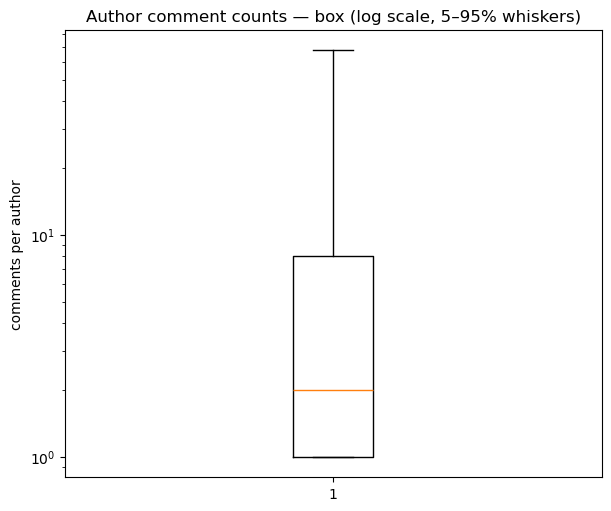

In [79]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 5), layout="constrained")
ax.boxplot(s, showfliers=False, whis=(5, 95))  # whiskers at 5th–95th percentiles
ax.set_yscale("log")
ax.set_ylabel("comments per author")
ax.set_title("Author comment counts — box (log scale, 5–95% whiskers)")
plt.show()

In [81]:
comments_2 = comments.query("video_id>=20").reset_index(drop=True)

In [85]:
comments.shape

(448810483, 2)

In [89]:
# ========== CONFIG ==========
BASE         = base  # <-- change this
IN_FILENAME  = "youtube_comments.tsv.gz"    
OUT_FILENAME = "youtube_comments_p90.tsv.gz" 
CHUNK_ROWS   = 5_000_000                     
PCT          = 0.90                           

path_in  = BASE / IN_FILENAME
path_out = BASE / OUT_FILENAME
# ===========================


def authors_from_percentile(commenters: pd.DataFrame,
                            percentile: float,
                            author_col: str = "author",
                            count_col: str | None = None) -> set[str]:
    df = commenters.copy()
    if count_col is None:
        if "num_comments" in df.columns:
            count_col = "num_comments"
        elif "count" in df.columns:
            count_col = "count"
        elif "video_id" in df.columns and pd.api.types.is_numeric_dtype(df["video_id"]):
            count_col = "video_id"
        else:
            raise ValueError("Couldn't infer the count column; pass count_col explicitly.")

    if author_col not in df.columns:
        raise ValueError(f"'{author_col}' column not found in commenters.")

    df[author_col] = df[author_col].astype("string")
    df[count_col]  = pd.to_numeric(df[count_col], errors="coerce").fillna(0)

    thr = df[count_col].quantile(percentile)
    keep = set(df.loc[df[count_col] >= thr, author_col].astype(str))
    print(f"[P{int(percentile*100)}] threshold={int(thr)}; keeping {len(keep):,} authors")
    return keep

def detect_usecols(path_in: Path) -> list[str]:
    want = ["author", "video_id", "likes", "replies"]
    with gzip.open(path_in, "rt", encoding="utf-8", newline="") as fh:
        header = fh.readline().rstrip("\n").split("\t")
    cols = [c for c in want if c in header]
    if "author" not in cols or "video_id" not in cols:
        raise ValueError(f"Required columns missing. Found header: {header}")
    return cols

def dtypes_for(cols: list[str]) -> dict:
    dt = {}
    if "author"   in cols: dt["author"]   = "string"
    if "video_id" in cols: dt["video_id"] = "string"
    if "likes"    in cols: dt["likes"]    = "Int32"
    if "replies"  in cols: dt["replies"]  = "Int32"
    return dt

def write_rows_for_authors(path_in: Path, authors_keep: set[str], path_out: Path, chunk_rows: int = CHUNK_ROWS):
    cols   = detect_usecols(path_in)
    dtypes = dtypes_for(cols)
    authors_keep = {str(a) for a in authors_keep} 

    written = 0
    with gzip.open(path_out, "wt", encoding="utf-8", newline="\n") as out:
        out.write("\t".join(cols) + "\n")
        rdr = pd.read_csv(
            path_in, sep="\t", compression="gzip",
            usecols=cols, dtype=dtypes,
            chunksize=chunk_rows, on_bad_lines="skip",
        )
        for i, chunk in enumerate(rdr, 1):
            # make sure dtype matches the set
            if chunk["author"].dtype.name != "string":
                chunk["author"] = chunk["author"].astype("string")
            sub = chunk[chunk["author"].isin(authors_keep)]
            if not sub.empty:
                sub.to_csv(out, sep="\t", index=False, header=False)
                written += len(sub)
            if i % 50 == 0:
                print(f"[WRITE] processed ~{i*chunk_rows:,} rows; written {written:,}")
    print(f"Done. Wrote {written:,} rows → {path_out}")

In [ ]:
authors_keep = authors_from_percentile(
    comments, percentile=PCT, author_col="author", count_col="video_id")
write_rows_for_authors(path_in, authors_keep, path_out, CHUNK_ROWS)

## just trial

In [7]:
file = base / "yt_metadata_helper.feather"
df = pd.read_feather(file)

print("rows:", len(df))
print("columns:", df.columns[:10])  # show first 10 column names

rows: 72924794
columns: Index(['categories', 'channel_id', 'dislike_count', 'display_id', 'duration',
       'like_count', 'upload_date', 'view_count'],
      dtype='object')


In [13]:
import pandas as pd
import numpy as np
from itertools import combinations
from collections import defaultdict
from pathlib import Path

try:
    from caas_jupyter_tools import display_dataframe_to_user
except Exception:
    display_dataframe_to_user = None

valid_videos = set(df["display_id"].astype(str).unique())
comments = comments.copy()
comments["author"] = comments["author"].astype(str)
comments["video_id"] = comments["video_id"].astype(str)

if len(valid_videos) > 0:
    comments = comments[comments["video_id"].isin(valid_videos)].copy()
authors_per_video = (
    comments.groupby("video_id")["author"]
    .apply(lambda s: sorted(set(s.astype(str))))
    .to_dict()
)

# Count co-occurrences across videos (edge weights)
edge_weights = defaultdict(int)
node_set = set()
for vid, authors in authors_per_video.items():
    node_set.update(authors)
    if len(authors) < 2:
        continue
    for a, b in combinations(authors, 2):
        if a == b: 
            continue
        key = (a, b) if a < b else (b, a)
        edge_weights[key] += 1

nodes = sorted(node_set)
node_idx = {n:i for i,n in enumerate(nodes)}
used_algo = None
labels = None

try:
    import igraph as ig
    import leidenalg as la
    g = ig.Graph()
    g.add_vertices(len(nodes))
    g.vs["name"] = nodes

    if edge_weights:
        edges = [(node_idx[a], node_idx[b]) for (a,b), w in edge_weights.items() if w > 0]
        weights = [w for (a,b), w in edge_weights.items() if w > 0]
        g.add_edges(edges)
        g.es["weight"] = weights
    else:
        edges = []
        weights = []
    part = la.find_partition(g, la.ModularityVertexPartition, weights=g.es["weight"] if "weight" in g.es.attributes() else None)
    labels = np.array(part.membership)
    used_algo = f"Leiden (modularity), communities={len(set(labels))}"
except Exception as e_leiden:
    try:
        import networkx as nx
        import community as community_louvain

        G = nx.Graph()
        G.add_nodes_from(nodes)
        for (a,b), w in edge_weights.items():
            G.add_edge(a, b, weight=w)

        if G.number_of_edges() == 0:
            labels = np.zeros(len(nodes), dtype=int)
            used_algo = "Trivial (no edges)"
        else:
            partition = community_louvain.best_partition(G, weight="weight", random_state=42)
            # map node -> label array
            labels = np.array([partition[n] for n in nodes])
            used_algo = f"Louvain, communities={len(set(labels))}"
    except Exception as e_louvain:
        # Fallback to NetworkX greedy modularity
        import networkx as nx
        G = nx.Graph()
        G.add_nodes_from(nodes)
        for (a,b), w in edge_weights.items():
            G.add_edge(a, b, weight=w)

        if G.number_of_edges() == 0:
            labels = np.zeros(len(nodes), dtype=int)
            used_algo = "Trivial (no edges)"
        else:
            comms = list(nx.algorithms.community.greedy_modularity_communities(G, weight="weight"))
            # assign cluster ids
            node2lab = {}
            for i, com in enumerate(comms):
                for n in com:
                    node2lab[str(n)] = i
            labels = np.array([node2lab.get(n, -1) for n in nodes])
            used_algo = f"NetworkX Greedy Modularity, communities={len(comms)}"

OSError: Cannot save file into a non-existent directory: '/mnt/data'

In [15]:
out = pd.DataFrame({
    "author": nodes,
    "cluster": labels
})

sizes = out["cluster"].value_counts().rename_axis("cluster").reset_index(name="cluster_size")
out = out.merge(sizes, on="cluster", how="left")
deg = defaultdict(int)
wdeg = defaultdict(float)
for (a,b), w in edge_weights.items():
    deg[a] += 1
    deg[b] += 1
    wdeg[a] += w
    wdeg[b] += w

out["degree"] = out["author"].map(lambda x: deg.get(x, 0))
out["weighted_degree"] = out["author"].map(lambda x: wdeg.get(x, 0.0))

# Optionally, attach simple activity stats (how many distinct videos, total comments by author)
author_vids = comments.groupby("author")["video_id"].nunique().rename("distinct_videos")
author_rows = comments.groupby("author")["video_id"].size().rename("comment_rows")
out = out.merge(author_vids, on="author", how="left").merge(author_rows, on="author", how="left")

# Save
out_path = base /"author_leiden_clusters.csv"
out.sort_values(["cluster","weighted_degree","degree","author"], ascending=[True, False, False, True]).to_csv(out_path, index=False)

# Show preview
preview = out.sort_values(["cluster","weighted_degree","degree","author"], ascending=[True, False, False, True]).head(20)
if display_dataframe_to_user:
    display_dataframe_to_user(f"Author clusters ({used_algo}) — preview", preview)

out_path, used_algo

(PosixPath('/Users/es/Downloads/4650046_files/author_leiden_clusters.csv'),
 'Leiden (modularity), communities=3823')

In [21]:
out.head()

,author,cluster,cluster_size,degree,weighted_degree,distinct_videos,comment_rows
0,1,8,100,1,1.0,5,5
1,10,126,1,0,0.0,3,3
2,100,127,1,0,0.0,1,2
3,1001,128,1,0,0.0,1,1
4,1002,129,1,0,0.0,1,1
